<a href="https://colab.research.google.com/github/asiddiqha/ai-workbench/blob/main/KMeansForIris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

In [22]:
iris = load_iris()

In [23]:
import pandas as pd
X = pd.DataFrame(iris.data)
X.columns = iris.feature_names
y = iris.target

In [24]:
X.shape

(150, 4)

<Axes: xlabel='sepal length (cm)', ylabel='sepal width (cm)'>

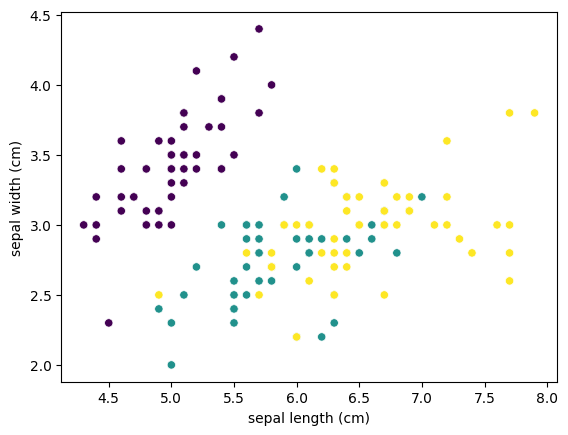

In [25]:
import seaborn as sns

# Visualize

sns.scatterplot(x=X.iloc[:,0], y=X.iloc[:,1], c=y)

In [26]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [27]:
# Elbow method
wscc = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    wscc.append(kmeans.inertia_)

<Axes: >

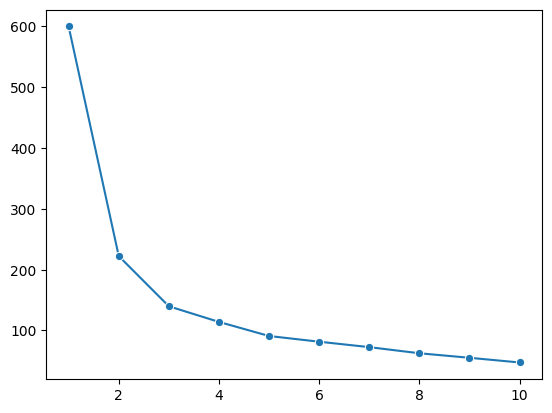

In [28]:
sns.lineplot(x=list(range(1,11)), y=wscc, marker='o')

<Axes: xlabel='sepal length (cm)', ylabel='sepal width (cm)'>

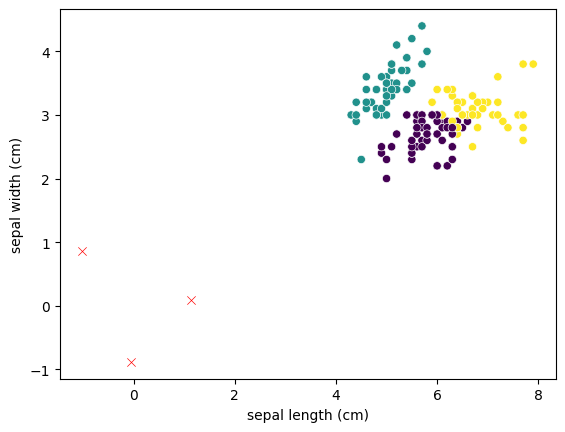

In [29]:
# K-Means
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, n_init=10, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

sns.scatterplot(x=X.iloc[:,0], y=X.iloc[:,1], c=y_kmeans)
sns.scatterplot(x=kmeans.cluster_centers_[:,0], y=kmeans.cluster_centers_[:,1], c='red', marker='x')

In [30]:
# Dimentionality Reduction using PCA

from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

<Axes: >

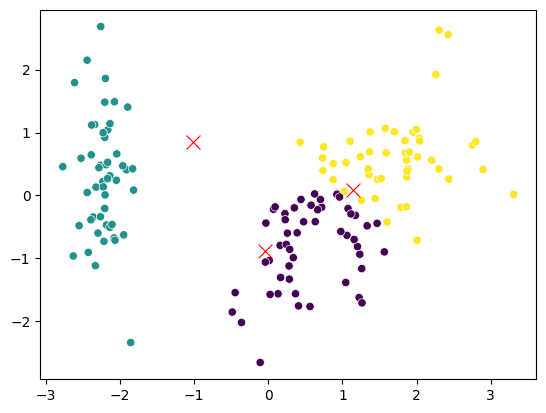

In [33]:
# PCA Data
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], c=y_kmeans)
sns.scatterplot(x=kmeans.cluster_centers_[:,0], y=kmeans.cluster_centers_[:,1], c='red', marker='x', s=100 )